In [130]:
import pandas as pd
import sklearn.cluster as cluster
import matplotlib.pyplot as plt

In [131]:
#Učitavamo dataset sa svim podacima i oučavamo kolone kao i tipove kolona
#Dakle vidimo da imamo 15 kolona od kojih su većina numeričke izuzev kolona Gender i Workout_Type
df_svi_clanovi = pd.read_csv('./data/gym_members_exercise_tracking.csv')
df_svi_clanovi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [132]:
#Prikaz nekoliko redova samog dataset-a
df_svi_clanovi.head(10)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
5,56,Female,58.0,1.68,168,156,74,1.59,1116.0,HIIT,15.5,2.7,5,3,20.55
6,36,Male,70.3,1.72,174,169,73,1.49,1385.0,Cardio,21.3,2.3,3,2,23.76
7,40,Female,69.7,1.51,189,141,64,1.27,895.0,Cardio,30.6,1.9,3,2,30.57
8,28,Male,121.7,1.94,185,127,52,1.03,719.0,Strength,28.9,2.6,4,2,32.34
9,28,Male,101.8,1.84,169,136,64,1.08,808.0,Cardio,29.7,2.7,3,1,30.07


In [133]:
#Dataset ćemo podeliti na dva podskupa  (Male, Female) - klasterizaciju ćemo sprovesti odvojeno za svaki podskup, s obzirom da se telesni parametri muških i ženskih članova značajno razlikuju.U ovoj skripti ce biti opisana klasterizacija za muške članove.

muski_clanovi = df_svi_clanovi[df_svi_clanovi["Gender"] == "Male"].copy()

In [134]:
#Sada vršimo ponovo pregled kolona i vidimo drugi broj redova,budući da više nemamo redove za ženske članove
muski_clanovi.info()
muski_clanovi.head(20)

<class 'pandas.core.frame.DataFrame'>
Index: 511 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            511 non-null    int64  
 1   Gender                         511 non-null    object 
 2   Weight (kg)                    511 non-null    float64
 3   Height (m)                     511 non-null    float64
 4   Max_BPM                        511 non-null    int64  
 5   Avg_BPM                        511 non-null    int64  
 6   Resting_BPM                    511 non-null    int64  
 7   Session_Duration (hours)       511 non-null    float64
 8   Calories_Burned                511 non-null    float64
 9   Workout_Type                   511 non-null    object 
 10  Fat_Percentage                 511 non-null    float64
 11  Water_Intake (liters)          511 non-null    float64
 12  Workout_Frequency (days/week)  511 non-null    int64  


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
6,36,Male,70.3,1.72,174,169,73,1.49,1385.0,Cardio,21.3,2.3,3,2,23.76
8,28,Male,121.7,1.94,185,127,52,1.03,719.0,Strength,28.9,2.6,4,2,32.34
9,28,Male,101.8,1.84,169,136,64,1.08,808.0,Cardio,29.7,2.7,3,1,30.07
10,41,Male,120.8,1.67,188,146,54,0.82,593.0,HIIT,20.5,3.0,2,1,43.31
11,53,Male,51.7,1.70,175,152,72,1.15,865.0,HIIT,23.6,3.5,3,2,17.89
12,57,Male,112.5,1.61,195,165,61,1.24,1013.0,Cardio,22.1,2.7,3,2,43.40
13,41,Male,94.5,2.00,179,136,69,1.18,794.0,HIIT,27.6,3.7,3,1,23.62


In [135]:
#Sada kada dataset ima samo muške članove, prelazimo na sređivanje podataka, prvo ćemo razmotriti koje kolone bi možda trebalo izbaciti
#Prva kolona koju bi izbacili jeste Gender, nema smisla zadržati je posto su joj sve vrednosti iste, jer smo tako podelili dataset, zbog što validnijih rezultata klasterizacije
#Workout_Type izbacujemo jer je tekstualna promenljiva (tip treninga) bez pravog redosleda.Kad bismo je pretvorili u brojeve, algoritam bi te brojeve shvatio kao rastojanja među kategorijama, a to nema smisla jer npr. "Yoga" nije bliža od "HIIT-a" na neki realan nacin, nije realno porediti
#Experience_Level izbacujemo iz klasterizacije jer zelimo da pronađemo grupe na osnovu fizičkih parametara, bez da unapred znamo koji je nivo iskustva - kasnije ćemo dobijene klastere uporediti sa ovom kolonom da vidimo da li se poklapaju, zato, je odvajamo sa strane
experience_level = muski_clanovi['Experience_Level']
#Izbacujemo te tri kolone i vršimo ponovo pregled dataset-a:
muski_clanovi.drop(columns=["Gender", "Workout_Type", "Experience_Level"], inplace=True)

muski_clanovi.info()

<class 'pandas.core.frame.DataFrame'>
Index: 511 entries, 0 to 972
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            511 non-null    int64  
 1   Weight (kg)                    511 non-null    float64
 2   Height (m)                     511 non-null    float64
 3   Max_BPM                        511 non-null    int64  
 4   Avg_BPM                        511 non-null    int64  
 5   Resting_BPM                    511 non-null    int64  
 6   Session_Duration (hours)       511 non-null    float64
 7   Calories_Burned                511 non-null    float64
 8   Fat_Percentage                 511 non-null    float64
 9   Water_Intake (liters)          511 non-null    float64
 10  Workout_Frequency (days/week)  511 non-null    int64  
 11  BMI                            511 non-null    float64
dtypes: float64(7), int64(5)
memory usage: 51.9 KB


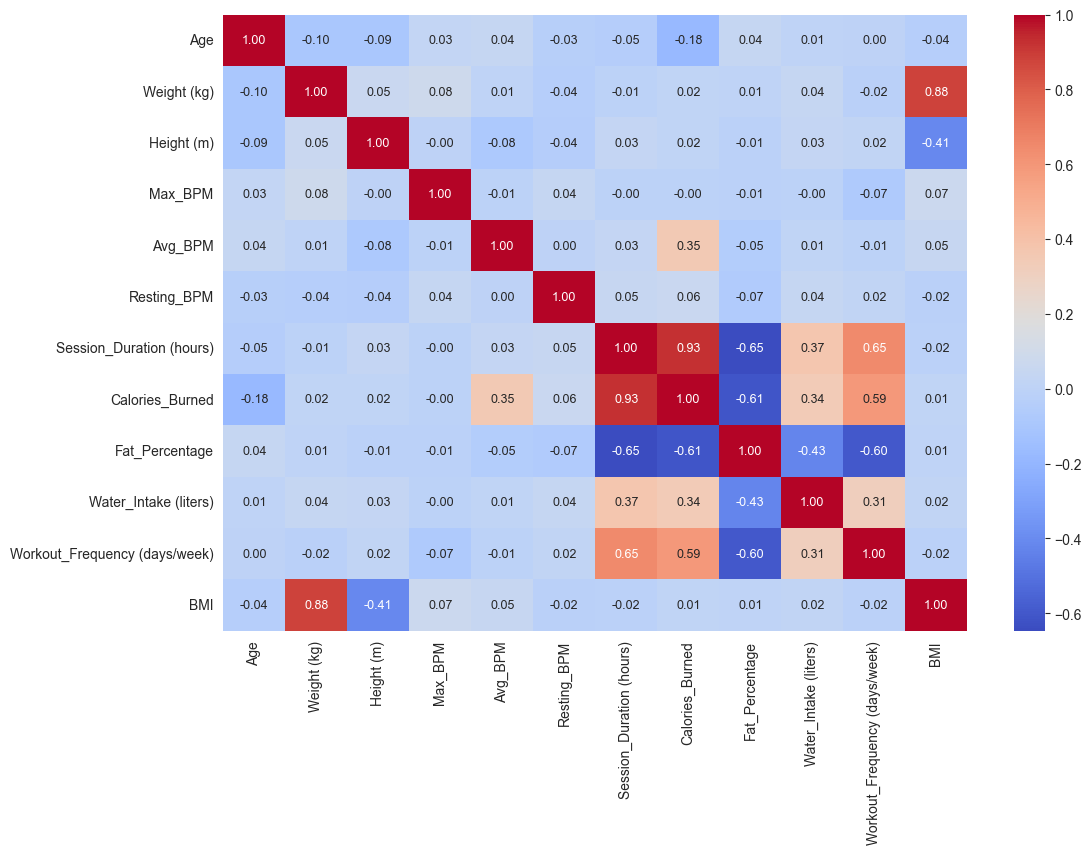

In [136]:
import seaborn as sb
#Što se tiče dalje pripreme podataka trebali bi da obratimo pažnju na NaN vrednosti ali u ovom dataset-u vidimo da istih nema ali važno je napomenuti da u slučaju da postoje NaN vrednosti, to bi se tretiralo na jedan od sledećih načina:
# 1.Izbacivanjem celih redova(ako neki red ima puno nedostajućih vrednosti)
# 2.Izbacivanjem celih promenljivih (ako neka promenljiva ima puno NaN vrednosti)
# 3.Zamenom NaN vrednosti npr. medijanom ili prosekom za tu promenljivu
# Dalje pošto su nam sve preostale promenljive numeričkog tipa nemamo potrebe da vršimo transformaciju kategorijskih promenljivih u numeričke
# Preostaje da proverimo korelacije između promenljivih


plt.figure(figsize=(12, 8))

sb.heatmap(muski_clanovi.corr(), annot=True,fmt=".2f",annot_kws={"size": 9},cmap="coolwarm")

plt.show()

In [137]:
#Iz matrice vidimo dva para promenljivih za koje bi rekli da su velike korelacije:
# 1.Weight(kg) i Bmi sa vrednošću 0.88
# 2.Session_Duration i Calories_Burned sa vrednošću 0.93
# Sve ostale korelacije npr. Session_Duration-Fat_Percentage = -0.65, Workout_Frequency-Fat_Percentage = -0.60 su umerene,dakle nisu prešle prag od 0,7 ili 0,8 pa ne zahtevaju izbacivanje
#Izbacićemo promenljivu "BMI" jer je matematički izvedena iz Weight i Height (BMI = težina/visina²), pa ne nosi novu informaciju,a korelacija od 0.88 sa Weight to potvrđuje.
#Izbacujemo promenljivu "Calories_Burned" jer je broj sagorenih kalorija usko povezan sa dužinom treninga (korelacija 0.93)

muski_clanovi.drop(columns=["BMI", "Calories_Burned"], inplace=True)
muski_clanovi.info()

<class 'pandas.core.frame.DataFrame'>
Index: 511 entries, 0 to 972
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            511 non-null    int64  
 1   Weight (kg)                    511 non-null    float64
 2   Height (m)                     511 non-null    float64
 3   Max_BPM                        511 non-null    int64  
 4   Avg_BPM                        511 non-null    int64  
 5   Resting_BPM                    511 non-null    int64  
 6   Session_Duration (hours)       511 non-null    float64
 7   Fat_Percentage                 511 non-null    float64
 8   Water_Intake (liters)          511 non-null    float64
 9   Workout_Frequency (days/week)  511 non-null    int64  
dtypes: float64(5), int64(5)
memory usage: 43.9 KB


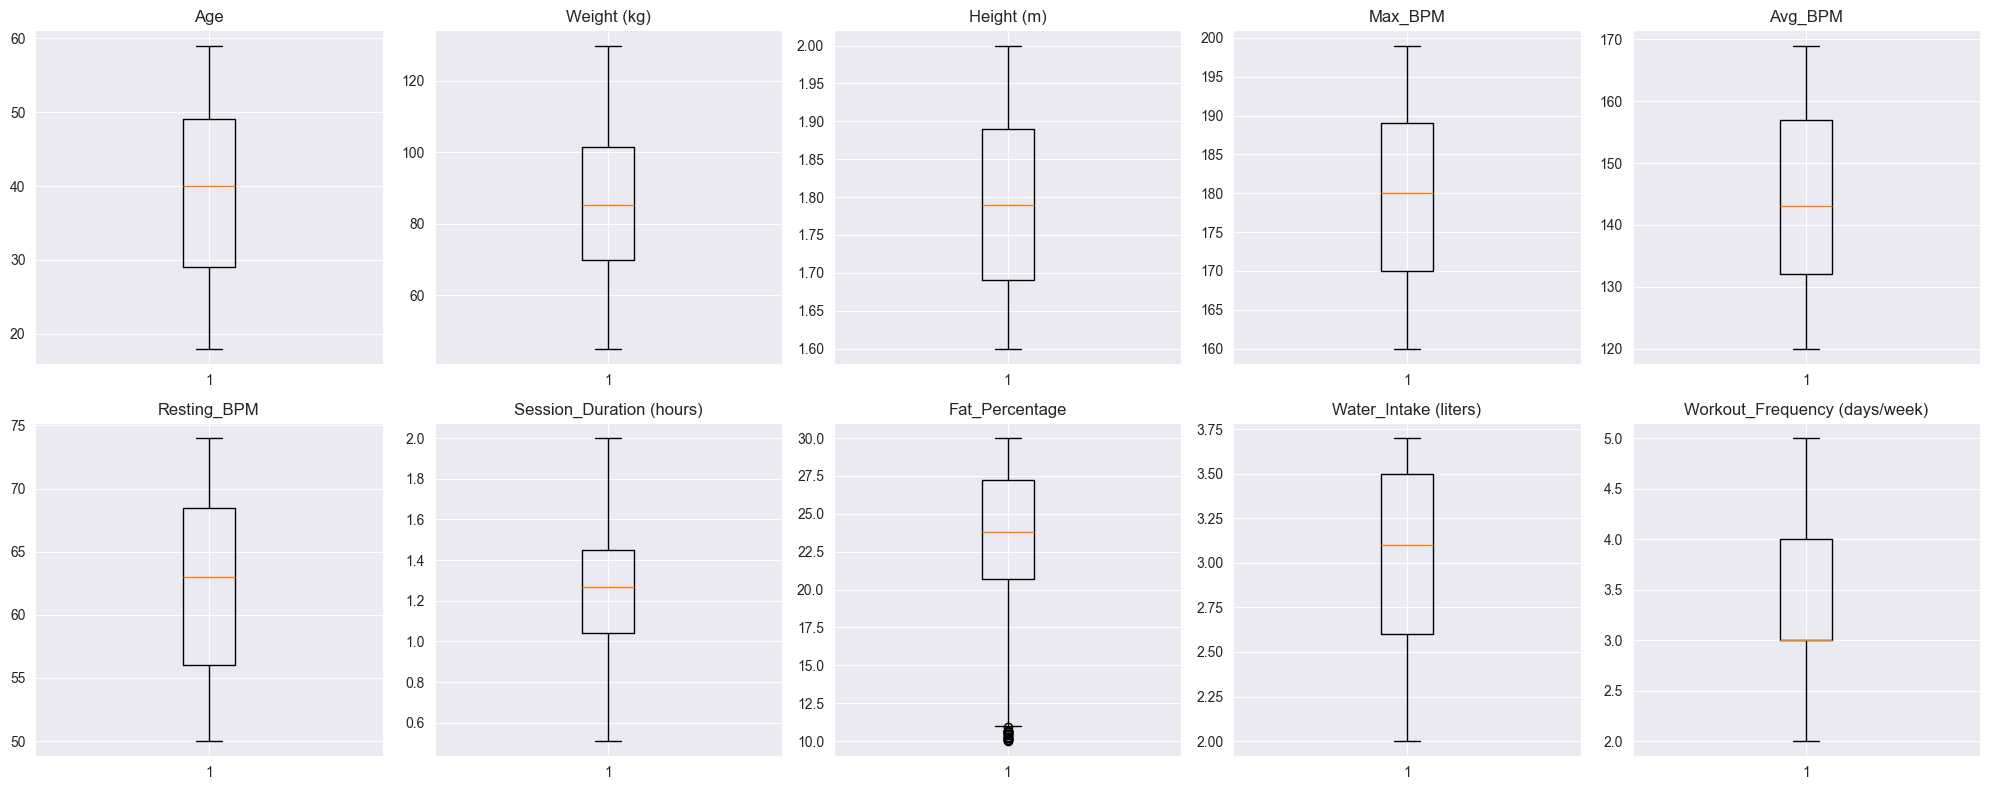

In [138]:
# Sledeće sto želimo da proverimo su outlier-i, pravimo poseban boxplot za svaku promenljivu, jer imaju veoma različite
# raspone vrednosti (npr. Weight ide do 130, a Height do 2), pa bi ih zajednički prikaz na istoj skali učinio nepreglednim
kolone = ["Age", "Weight (kg)", "Height (m)", "Max_BPM", "Avg_BPM",
          "Resting_BPM", "Session_Duration (hours)", "Fat_Percentage",
          "Water_Intake (liters)", "Workout_Frequency (days/week)"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

axes = axes.flatten()


for i, kolona in enumerate(kolone):
    axes[i].boxplot(muski_clanovi[kolona])
    axes[i].set_title(kolona)

plt.tight_layout()
plt.show()

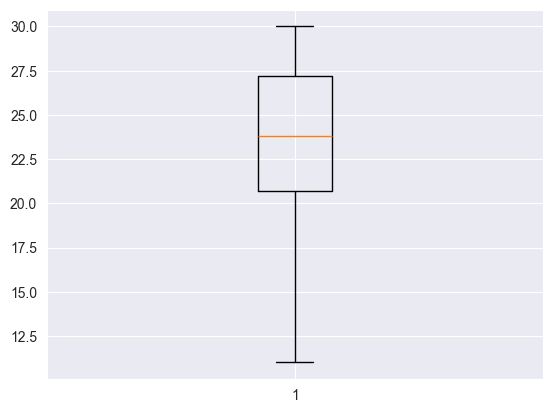

In [139]:
from scipy.stats.mstats import winsorize
import numpy as np
#Vidimo da outlier-i postoje sa donje strane u koloni Fat_Percantage,a ostale kolone izgledaju okej
#Zato ćemo uraditi winsorization za tu promenljivu:

#Odozgo ne želimo ništa da odsecamo jer nemamo gore outlier-e vec dole,tako da je drugi parametar 0
wins = winsorize(muski_clanovi["Fat_Percentage"], limits = [0.04, 0])

plt.boxplot(wins)
plt.show()

#Kada se uradi winsorize od 0.96 do 0 percentila eliminišu se svi outlier-i


#Zamenjujemo sa winsorize vrednostima, stavljamo np.asarray zbog warning-a jer je funkcija winsorize vratila MaskedArray,pa Pandas izbacuje upozorenje kada izračunava kvantiile unutar .describe()
muski_clanovi["Fat_Percentage"]=np.asarray(wins)


In [140]:
from sklearn.preprocessing import MinMaxScaler
# Sledeće što je potrebno jeste izvršiti normalizaciju(skaliranje) promenljivih jer su na različitim rasponima vrednosti
# (npr. Weight do 129, Height do 2)

#Podaci pre normalizacije:
muski_clanovi.describe()






,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week)
count,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000
mean,38.998043,85.531115,1.793405,179.996086,143.898239,62.320939,1.252446,22.576712,3.007436,3.305284
std,12.045258,21.788629,0.117081,11.678873,14.300193,7.403943,0.344297,5.681986,0.494146,0.927125
min,18.000000,45.000000,1.600000,160.000000,120.000000,50.000000,0.510000,11.000000,2.000000,2.000000
25%,29.000000,69.750000,1.690000,170.000000,132.000000,56.000000,1.040000,20.700000,2.600000,3.000000
50%,40.000000,85.300000,1.790000,180.000000,143.000000,63.000000,1.270000,23.800000,3.100000,3.000000
75%,49.000000,101.600000,1.890000,189.000000,157.000000,68.500000,1.450000,27.200000,3.500000,4.000000
max,59.000000,129.900000,2.000000,199.000000,169.000000,74.000000,2.000000,30.000000,3.700000,5.000000


In [141]:
#Podaci nakon normalizacije
muski_clanovi = pd.DataFrame(MinMaxScaler().fit_transform(muski_clanovi), columns=muski_clanovi.columns)
muski_clanovi.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week)
count,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000
mean,0.512147,0.477398,0.483513,0.512720,0.487719,0.513372,0.498286,0.609301,0.592610,0.435095
std,0.293787,0.256639,0.292703,0.299458,0.291841,0.308498,0.231071,0.299052,0.290674,0.309042
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.268293,0.291519,0.225000,0.256410,0.244898,0.250000,0.355705,0.510526,0.352941,0.333333
50%,0.536585,0.474676,0.475000,0.512821,0.469388,0.541667,0.510067,0.673684,0.647059,0.333333
75%,0.756098,0.666667,0.725000,0.743590,0.755102,0.770833,0.630872,0.852632,0.882353,0.666667
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


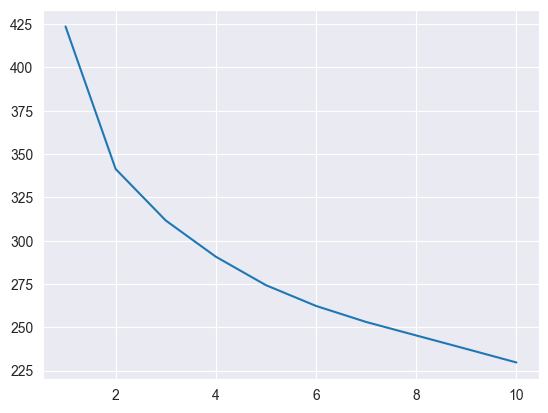

In [142]:
#Kada smo pripremili dataset za klasterizaciju, prvo ćemo obraditi kmeans klasterizaciju i prvo što je potrebno jeste da primenom elbow metode odredimo optimalno k
wcss = []

for i in range(1,11):
    kmeans = cluster.KMeans(n_clusters=i, init="k-means++", n_init= 1000, max_iter=100, random_state=0).fit(muski_clanovi)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.show()

k=2: silhouette score = 0.2203
k=3: silhouette score = 0.1431
k=4: silhouette score = 0.1402
k=5: silhouette score = 0.1417
k=6: silhouette score = 0.1376
k=7: silhouette score = 0.1361
k=8: silhouette score = 0.1352
k=9: silhouette score = 0.1109
k=10: silhouette score = 0.1145


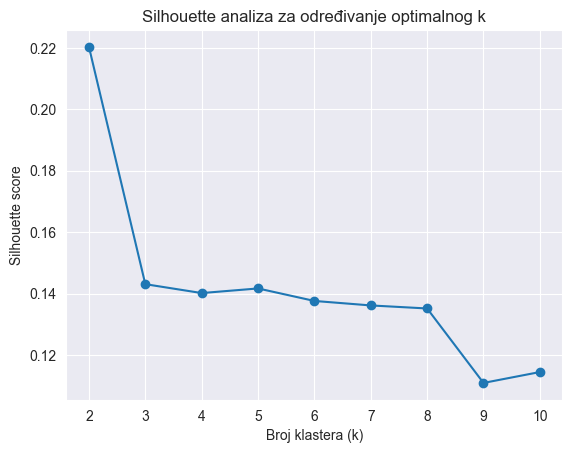

In [143]:
#Pošto elbow metoda ukazuje na k=2 i vidimo blagi lakat na k=3, računamo silhouette score za te i okolne vrednosti k kako bismo imali dodatnu potvrdu izbora optimalnog broja klastera, a ne samo vizuelnu procenu sa grafika

from sklearn.metrics import silhouette_score

silhouette_scores = []
for i in range(2, 11):
    kmeans = cluster.KMeans(n_clusters=i, init="k-means++", n_init=1000, max_iter=100, random_state=0).fit(muski_clanovi)
    score = silhouette_score(muski_clanovi, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"k={i}: silhouette score = {score:.4f}")

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel("Broj klastera (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette analiza za određivanje optimalnog k")
plt.show()

In [144]:
#Silhouette analiza je potvrdila k=2 kao optimalan broj klastera (score = 0.2203), što je značajno viša vrednost u odnosu na sve ostale ispitane vrednosti k (0.11-0.14), čime je isključena mogućnost da je k=3 bolji izbor uprkos blagom pregibu uočenom na elbow grafiku
#Vršimo klasterizaciju za k=2:
kmeans = cluster.KMeans(n_clusters = 2, init="k-means++", n_init=1000, max_iter=100, random_state=0).fit(muski_clanovi)

muski_clanovi_clusters = muski_clanovi.copy()
muski_clanovi_clusters["cluster"] = kmeans.labels_

muski_clanovi_clusters.head()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),cluster
0,0.926829,0.510012,0.275,0.512821,0.755102,0.416667,0.791946,0.084211,0.882353,0.666667,1
1,0.170732,0.096584,0.250,0.769231,0.897959,0.250000,0.053691,0.936842,0.058824,0.333333,0
2,0.487805,0.012956,0.475,0.717949,0.775510,0.750000,0.087248,0.957895,0.470588,0.333333,0
3,0.439024,0.297998,0.300,0.358974,1.000000,0.958333,0.657718,0.542105,0.176471,0.333333,0
4,0.243902,0.903416,0.850,0.641026,0.142857,0.083333,0.348993,0.942105,0.352941,0.666667,0


Klaster 1:  408
Klaster 2:  103


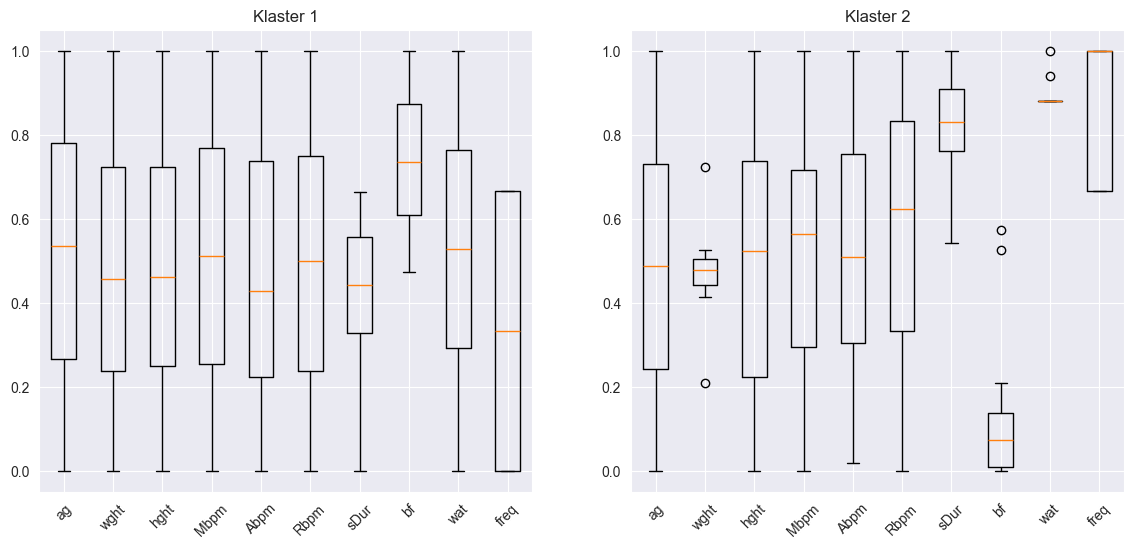

In [145]:
# Nakon klasterizacije za k=2, vršimo tumačenje dobijenih klastera (veličina, centralne vrednosti i disperzija)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].boxplot(muski_clanovi_clusters[muski_clanovi_clusters["cluster"]==0].drop(columns="cluster"), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq"])
ax[0].set_title("Klaster 1")

ax[1].boxplot(muski_clanovi_clusters[muski_clanovi_clusters["cluster"]==1].drop(columns="cluster"), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq"])
ax[1].set_title("Klaster 2")

for a in ax:
    a.tick_params(axis='x', rotation=45)

print("Klaster 1: ", muski_clanovi_clusters.loc[muski_clanovi_clusters["cluster"]==0, "cluster"].count())
print("Klaster 2: ", muski_clanovi_clusters.loc[muski_clanovi_clusters["cluster"]==1, "cluster"].count())

#Klasteri su značajne veličine sa tim što je klaster 1(408 članova) znatno veći od klastera 2(103 članova).
#Klaster 1 čine umereni vežbači čije vreme treninga je srednje(umereno), sa višim procentom masti i sa niskom do srednjom frekvencijom treninga nedeljno
#Klaster 2 čine posvećeni vežbači srednje težine, sa dužim trajanjem treninga, veoma niskim procentom masti, visokom frekvenicijom treninga (nedeljno) i većim unosom vode kao posledica intenzivnijih treninga.Ovaj klaster ima i blago više vrednosti prosecnog i mirujuceg pulsa

#Što se tiče homogenosti zavisno od parametara:
#Klaster 2 je homogeniji u odnosu na klaster 1 naročito po težini (uzak opseg vrednosti za drugi klaster),a klaster 1 obuhvata vežbače  šireg raspona težine i učestalosti treninga za razliku od klastera 2.

In [146]:
# Poredimo dobijene klastere sa stvarnim nivoom iskustva članova (Experience_Level),koji nije korišćen u samoj klasterizaciji - ovo nam služi kao provera da li klasteri koje je algoritam sam pronašao imaju smisla
muski_clanovi_clusters['Experience_Level'] = experience_level.values
pd.crosstab(muski_clanovi_clusters['cluster'], muski_clanovi_clusters['Experience_Level'])


# Poređenje sa kolonom Experience_Level pokazuje poklapanje:
# Klaster 1 (408 članova) sadrzi gotovo iskljucivo članove sa Experience_Level 1 i 2 (početnici i srednji nivo) - nijedan napredni član nije svrstan u ovaj klaster.
# Klaster 2 (103 člana) sadrzi 101 od 103 člana sa Experience_Level 3 (napredni nivo)
# Ovo pokazuje da je algoritam, iako nije imao pristup ovoj informaciji tokom klasterizacije, uspeo da dobro da predvidi klastere u odnosu na stvarni nivo iskustva članova samo na osnovu fizičkih parametara i karakteristika treninga.

Experience_Level,1,2,3
cluster,,,
0,197,211,0
1,0,2,101


In [147]:
#Iako Silhouette analiza i Elbow metoda pokazuju da je optimalan broj klastera 2, mi ćemo analizirati i slučaj za k=3 i uporediti i te rezultate budući da intuitivno i na osnovu kolone Expirience_Level ima smisla pokušati i izvršiti klasterizaciju za k=3
kmeans = cluster.KMeans(n_clusters = 3, init="k-means++", n_init=1000, max_iter=100, random_state=0).fit(muski_clanovi)

muski_clanovi_3clusters = muski_clanovi.copy()
muski_clanovi_3clusters["cluster"] = kmeans.labels_

muski_clanovi_3clusters.head(20)

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),cluster
0,0.926829,0.510012,0.275,0.512821,0.755102,0.416667,0.791946,0.084211,0.882353,0.666667,2
1,0.170732,0.096584,0.250,0.769231,0.897959,0.250000,0.053691,0.936842,0.058824,0.333333,1
2,0.487805,0.012956,0.475,0.717949,0.775510,0.750000,0.087248,0.957895,0.470588,0.333333,1
3,0.439024,0.297998,0.300,0.358974,1.000000,0.958333,0.657718,0.542105,0.176471,0.333333,0
4,0.243902,0.903416,0.850,0.641026,0.142857,0.083333,0.348993,0.942105,0.352941,0.666667,1
5,0.243902,0.669022,0.600,0.230769,0.326531,0.583333,0.382550,0.984211,0.411765,0.333333,0
6,0.560976,0.892815,0.175,0.717949,0.530612,0.166667,0.208054,0.500000,0.588235,0.000000,1
7,0.853659,0.078916,0.250,0.384615,0.653061,0.916667,0.429530,0.663158,0.882353,0.333333,0
8,0.951220,0.795053,0.025,0.897436,0.918367,0.458333,0.489933,0.584211,0.411765,0.333333,1
9,0.560976,0.583039,1.000,0.487179,0.326531,0.791667,0.449664,0.873684,1.000000,0.333333,0


Klaster 1:  217
Klaster 2:  192
Klaster 3:  102


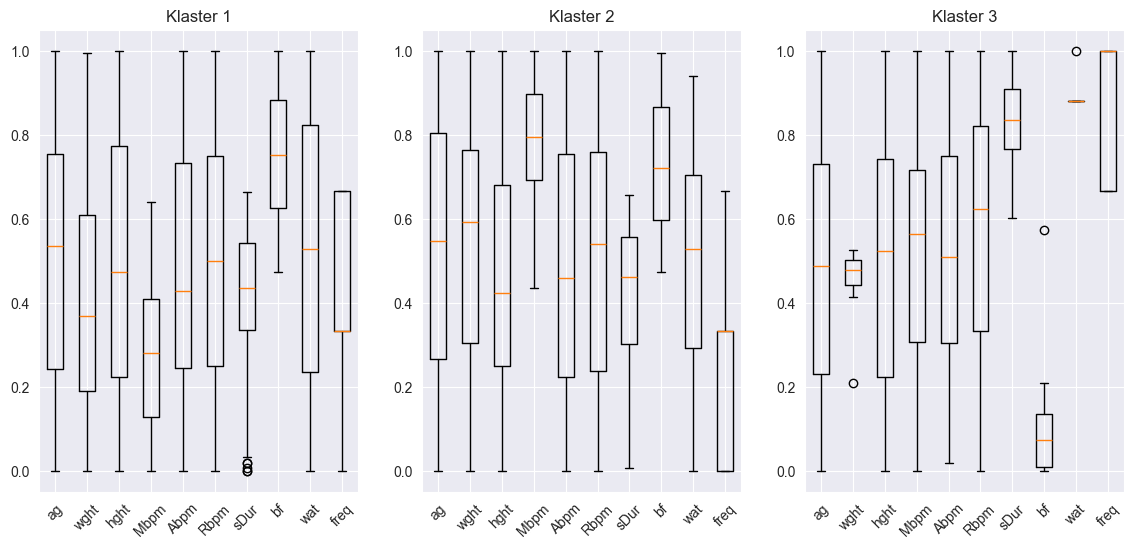

In [148]:
fig, ax = plt.subplots(1, 3, figsize=(14, 6))

ax[0].boxplot(muski_clanovi_3clusters[muski_clanovi_3clusters["cluster"]==0].drop(columns="cluster"), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq"])
ax[0].set_title("Klaster 1")

ax[1].boxplot(muski_clanovi_3clusters[muski_clanovi_3clusters["cluster"]==1].drop(columns="cluster"), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq"])
ax[1].set_title("Klaster 2")

ax[2].boxplot(muski_clanovi_3clusters[muski_clanovi_3clusters["cluster"]==2].drop(columns="cluster"), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq"])
ax[2].set_title("Klaster 3")

for a in ax:
    a.tick_params(axis='x', rotation=45)

print("Klaster 1: ", muski_clanovi_3clusters.loc[muski_clanovi_3clusters["cluster"]==0, "cluster"].count())
print("Klaster 2: ", muski_clanovi_3clusters.loc[muski_clanovi_3clusters["cluster"]==1, "cluster"].count())
print("Klaster 3: ", muski_clanovi_3clusters.loc[muski_clanovi_3clusters["cluster"]==2, "cluster"].count())

#Vidimo da su sva tri klastera značajne veličine, prvi sa 217 članova, drugi sa 192 i treći sa 102.
#Klaster 1 karakterišu vežbači sa nižim maksimalanim brojem otkucaja srca tokom treninga,sa prosečnim ili malo kraćim treninzima,visokim procentom telesne masti i srednjom frekvencijom treninga
#Klaster 2 čine vežbači sa visokim maksimalanim brojem otkucaja srca tokom treninga,sa prosečnim ili malo kraćim treninzima, visokim procentom telesne masti i jako niskom frekvencijom treninga
#Klaster 3 čine vežbači isključivo srednje težine, sa srednjim maksimalanim brojem otkucaja srca tokom treninga, čiji treninzi traju duže,sa niskim procentom masti,visokim unosom vode i visokom frekvencijom treninga
#Što se tiče homogenosti najhomogeniji je treći klaster jer su u pitanju ljudi izričito srednje težine,visokog unosa vode,niskog procenta masti i jako visoke frekvencije treninga
#Subjektivno tumačenje:Za klaster 1 bi rekli da su u pitanju rekreativci koji ulažu neki manji napor na treningu, ali su dosta redovni u teretani, a za klaster 2 bi se reklo da su to vežbači koji ulažu dosta truda na treningu ali i retko dolaze na isti, verovatno zbog velikih napora ili prevelike želje da postignu sve pa onda brzo odustanu jer ne mogu ispratiti proces.Klaster 3 bi bili napredni vežbači koji su redovni i utrenirani i koji vode računa o unosu vode.To što je srednji maksimalan broj otkucaja srca tokom treninga to ne znači da oni ne treniraju intenzivno već to je znak da je njihovo telo utrenirano i da retko koji napor za njih predstavlja prepreku.


In [149]:
# Uporedićemo i ove dobijene klastere sa stvarnim nivoom iskustva članova (Experience_Level),koji nije korišćen u samoj klasterizaciji
muski_clanovi_3clusters['Experience_Level'] = experience_level.values
pd.crosstab(muski_clanovi_3clusters['cluster'], muski_clanovi_3clusters['Experience_Level'])
# Poređenje sa Experience_Level pokazuje da k=3 ne donosi značajnu dodatnu vrednost u odnosu na k=2. Klaster 3 (102 člana) i dalje odgovara naprednim članovima (101 od 102 ima Experience_Level 3), identično kao i za k=2.Međutim, Klaster 1 i Klaster 2 gotovo podjednako dele clanove sa Experience_Level 1 i 2 (98 i 99 člana, odnosno 119 i 93 člana),sto znaci da razlika izmedju ta dva klastera ne prati nivo iskustva, već verovatno neki drugi aspekt treninga(intenzitet treninga verovatno).Ovo dodatno potvrdjuje da je k=2 bolji:jasno razdvaja pocetnu/srednju od napredne grupe, dok dalja podela na k=3 ne donosi jasniju sliku u odnosu na stvarni nivo iskustva članova.

Experience_Level,1,2,3
cluster,,,
0,98,119,0
1,99,93,0
2,0,1,101


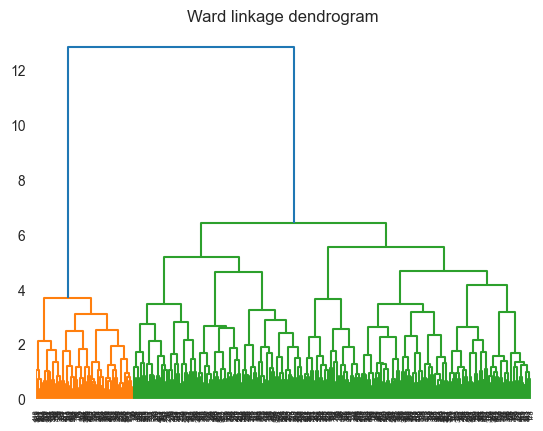

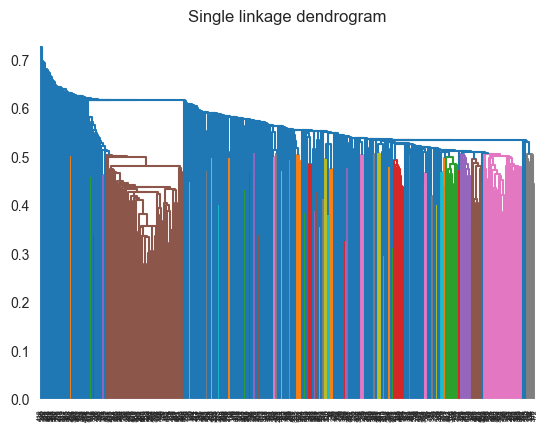

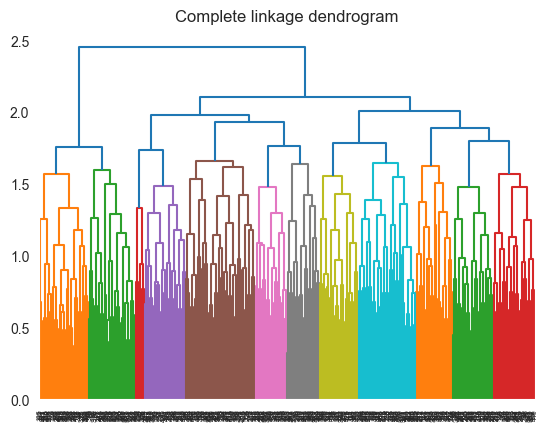

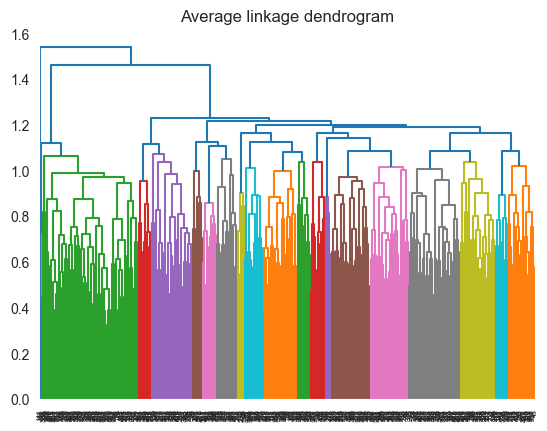

In [150]:
from scipy.cluster.hierarchy import linkage, dendrogram
#Sada prelazimo na hijarahijsku klasterizaciju, prvo što ćemo uraditi jeste crtanje dendrograma sa različitim linkage metodama i euklidskom razdaljinom i određujemo optimalno k
#Prikaz dendrograma za različite linkage metode:
dendrogram(linkage(muski_clanovi, method='ward', metric='euclidean'))
plt.title("Ward linkage dendrogram")
plt.show()

dendrogram(linkage(muski_clanovi, method='single', metric='euclidean'))
plt.title("Single linkage dendrogram")
plt.show()

dendrogram(linkage(muski_clanovi, method='complete', metric='euclidean'))
plt.title("Complete linkage dendrogram")
plt.show()

dendrogram(linkage(muski_clanovi, method='average', metric='euclidean'))
plt.title("Average linkage dendrogram")
plt.show()

In [151]:
# Od svih metoda najbolje deluje Ward linkage,kod single i average linkage postoji chaining efekat. Complete
# linkage opet pravi previše malih grupica. Ward daje najčistiju podelu, i logika mu je slična k-means-u, pa su i rezultati lakše uporedivi.
#Radimo hijerarhijsku klasterizaciju sa dva klastera i Ward linkage metodom, euklidska udaljenost
hclust = cluster.AgglomerativeClustering(n_clusters=2, linkage = "ward", metric="euclidean").fit(muski_clanovi)

# Pravimo novi dataset i dodajemo kolonu sa vrednostima klastera
h_muski_clanovi = muski_clanovi.copy()
h_muski_clanovi["cluster"] = hclust.labels_
h_muski_clanovi.head()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),cluster
0,0.926829,0.510012,0.275,0.512821,0.755102,0.416667,0.791946,0.084211,0.882353,0.666667,1
1,0.170732,0.096584,0.250,0.769231,0.897959,0.250000,0.053691,0.936842,0.058824,0.333333,0
2,0.487805,0.012956,0.475,0.717949,0.775510,0.750000,0.087248,0.957895,0.470588,0.333333,0
3,0.439024,0.297998,0.300,0.358974,1.000000,0.958333,0.657718,0.542105,0.176471,0.333333,0
4,0.243902,0.903416,0.850,0.641026,0.142857,0.083333,0.348993,0.942105,0.352941,0.666667,0


Klaster 1:  410
Klaster 2:  101


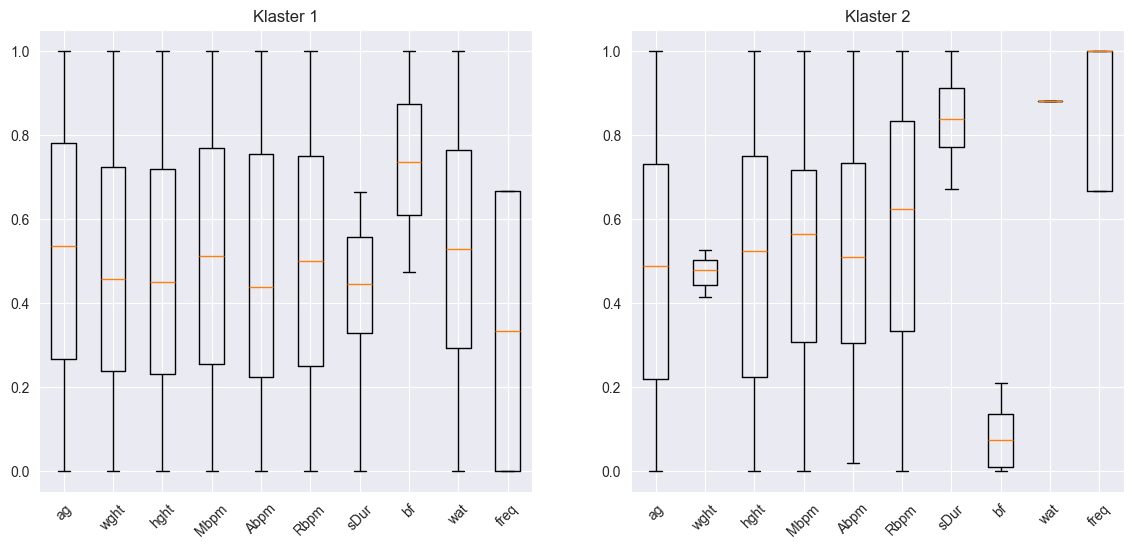

In [152]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].boxplot(h_muski_clanovi[h_muski_clanovi["cluster"]==0].drop(columns="cluster"), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq"])
ax[0].set_title("Klaster 1")

ax[1].boxplot(h_muski_clanovi[h_muski_clanovi["cluster"]==1].drop(columns="cluster"), tick_labels = ["ag","wght", "hght", "Mbpm", "Abpm", "Rbpm", "sDur", "bf", "wat", "freq"])
ax[1].set_title("Klaster 2")

for a in ax:
    a.tick_params(axis='x', rotation=45)

print("Klaster 1: ", h_muski_clanovi.loc[h_muski_clanovi["cluster"]==0, "cluster"].count())
print("Klaster 2: ", h_muski_clanovi.loc[h_muski_clanovi["cluster"]==1, "cluster"].count())
#Vidimo i ovde da su klasteri značajne veličine, dakle klaster 1(410 članova) je znatno veći od klastera 2(101 član)
#Klaster 1 takođe i ovde čine umereni vežbači sa umerenim trajanjem treninga, većim procentom telesne masti, nižom/srednjom
#učestalosti treninga
#Klaster 2 karakterišu napredni vežbači sa dužim trajanjem treninga, veoma niskim procentom masti,većom frekvencijom treninga i
#visokim unosom vode
#Klaster 2 je i u ovom slučaju homogeniji u odnosu na klaster 1 po tezini (jako uzak opseg vrednosti),a klaster 1 obuhvata vežbače šireg raspona težine i učestalosti treninga za razliku od klastera 2


In [153]:
# Uporedićemo dobijene klastere sa stvarnim nivoom iskustva članova (Experience_Level),kao i kada smo završili kMeans klasterizaciju


h_muski_clanovi['Experience_Level'] = experience_level.values
pd.crosstab(h_muski_clanovi['cluster'], h_muski_clanovi['Experience_Level'])

#Klaster 1 (410 članova) sadrzi isključivo clanove sa Experience_Level 1 i 2 (pocetnici i srednji nivo) - nijedan napredni član nije svrstan u ovaj klaster.
# Klaster 2 (101 članova) sadrži svih 101 članova sa Experience_Level 3 (napredni nivo)
# Algoritam, iako nije imao pristup ovoj informaciji tokom klasterizacije, uspeo je ponovo da dobro predvidi klastere u odnosu na stvarni nivo iskustva članova samo na osnovu fizičkih parametara i karakteristika treninga.



# Poređenje k-means i hijerarhijske (Ward) klasterizacije:
#
# Veličine klastera su identične (k-means: 408/103, hijerarhijska: 410/101),sto pokazuje da se dve nezavisne metode, zasnovane na razlicitim principima , slažu oko podele clanova u iste dve grupe.

# Interpretacija klastera je takođe identična kod obe metode: manji klaster  (100-103 člana) karakterisu duži i češći treninzi, nizak procenat telesne masti i veći unos vode - posvećeni vežbači.
# Veći klaster (408-410 clanova) karakteriše umereno trajanje i učestalost treninga i viši procenat telesne masti-rekreativni vezbaci.
#
# Ovakvo poklapanje između dve različite tehnike klasterizacije dovodi do zaključka da otkrivena podela nije slučajna, već predstavlja stvarnu, prirodnu strukturu u podacima.

Experience_Level,1,2,3
cluster,,,
0,197,213,0
1,0,0,101
